In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Plant_1_Generation_Data.csv to Plant_1_Generation_Data (1).csv
Saving Plant_1_Weather_Sensor_Data.csv to Plant_1_Weather_Sensor_Data.csv


In [ ]:
import pandas as pd

gen_df = pd.read_csv('Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'], format='%d-%m-%Y %H:%M')

weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='inner')

print("Veriler başarıyla birleştirildi!")
print(f"Toplam Satır Sayısı: {len(df)}")
df.head()

Veriler başarıyla birleştirildi!
Toplam Satır Sayısı: 68774


,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [ ]:
df_clean = df.drop(['PLANT_ID_x', 'SOURCE_KEY_x', 'PLANT_ID_y', 'SOURCE_KEY_y', 'TOTAL_Y_x', 'TOTAL_Y_y'], axis=1, errors='ignore')

df_clean['HOUR'] = df_clean['DATE_TIME'].dt.hour
df_clean['DAY'] = df_clean['DATE_TIME'].dt.day

print("Değişkenler Arasındaki İlişki (Korelasyon):")
correlation = df_clean.corr()
display(correlation['DC_POWER'].sort_values(ascending=False))

display(df_clean.head())

Değişkenler Arasındaki İlişki (Korelasyon):


,DC_POWER
DC_POWER,1.000000
AC_POWER,0.999996
IRRADIATION,0.989391
MODULE_TEMPERATURE,0.954811
AMBIENT_TEMPERATURE,0.724668
DAILY_YIELD,0.082243
DAY,0.033072
HOUR,0.024083
TOTAL_YIELD,0.003851
DATE_TIME,-0.029845


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY
0,2020-05-15,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,0,15
1,2020-05-15,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,0,15
2,2020-05-15,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,0,15
3,2020-05-15,0.0,0.0,0.0,7602960.0,25.184316,22.857507,0.0,0,15
4,2020-05-15,0.0,0.0,0.0,7158964.0,25.184316,22.857507,0.0,0,15


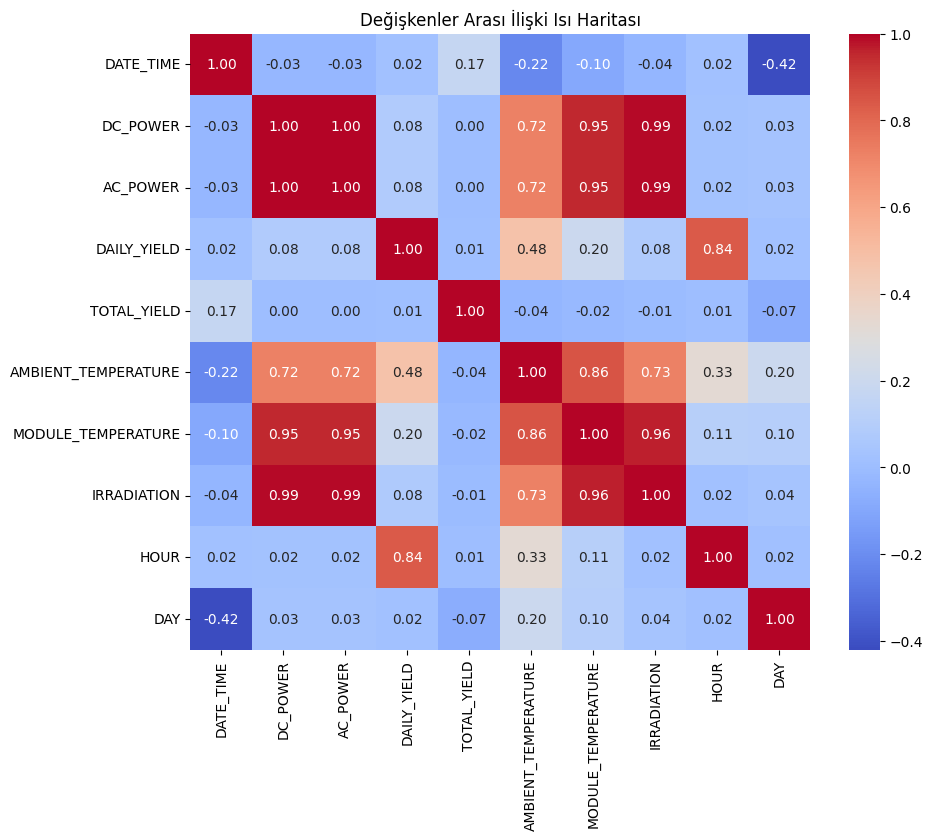

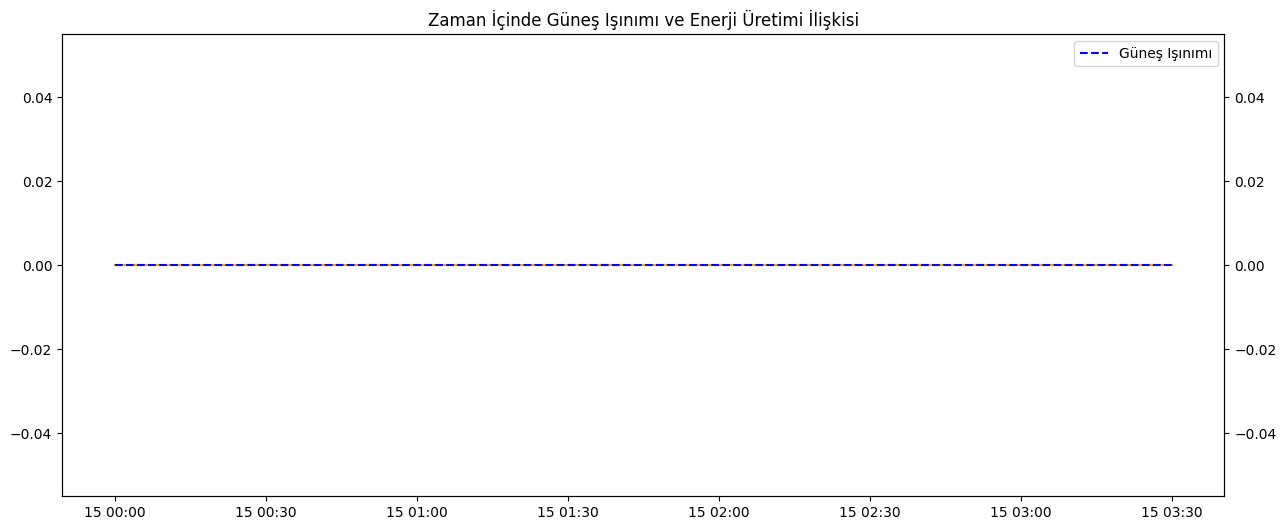

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Değişkenler Arası İlişki Isı Haritası')
plt.show()

sample_df = df_clean.head(300)
plt.figure(figsize=(15, 6))
plt.plot(sample_df['DATE_TIME'], sample_df['DC_POWER'], label='DC Üretim Gücü', color='orange')
plt.twinx()
plt.plot(sample_df['DATE_TIME'], sample_df['IRRADIATION'], label='Güneş Işınımı', color='blue', linestyle='--')
plt.title('Zaman İçinde Güneş Işınımı ve Enerji Üretimi İlişkisi')
plt.legend()
plt.show()

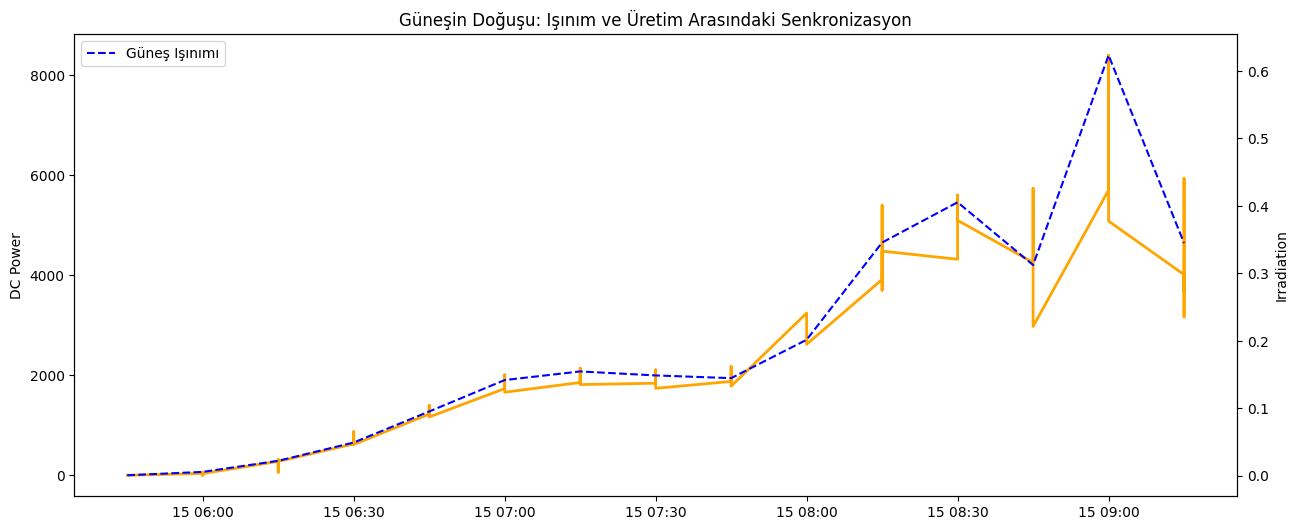

In [ ]:
sample_df = df_clean.iloc[500:800]

plt.figure(figsize=(15, 6))
plt.plot(sample_df['DATE_TIME'], sample_df['DC_POWER'], label='DC Üretim Gücü', color='orange', linewidth=2)
plt.ylabel('DC Power')
plt.twinx()
plt.plot(sample_df['DATE_TIME'], sample_df['IRRADIATION'], label='Güneş Işınımı', color='blue', linestyle='--')
plt.ylabel('Irradiation')
plt.title('Güneşin Doğuşu: Işınım ve Üretim Arasındaki Senkronizasyon')
plt.legend(loc='upper left')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df_clean[['AMBI_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'TIME']]
y = df_clean['DC_POWER']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
print("Model eğitiliyor, lütfen bekleyin...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Model Başarı Sonuçları ---")
print(f"R2 Skoru (Doğruluk Payı): %{r2_score(y_test, y_pred)*100:.2f}")
print(f"Ortalama Mutlak Hata (MAE): {mean_absolute_error(y_test, y_pred):.2f}")

Model eğitiliyor, lütfen bekleyin...

--- Model Başarı Sonuçları ---
R2 Skoru (Doğruluk Payı): %98.64
Ortalama Mutlak Hata (MAE): 168.38


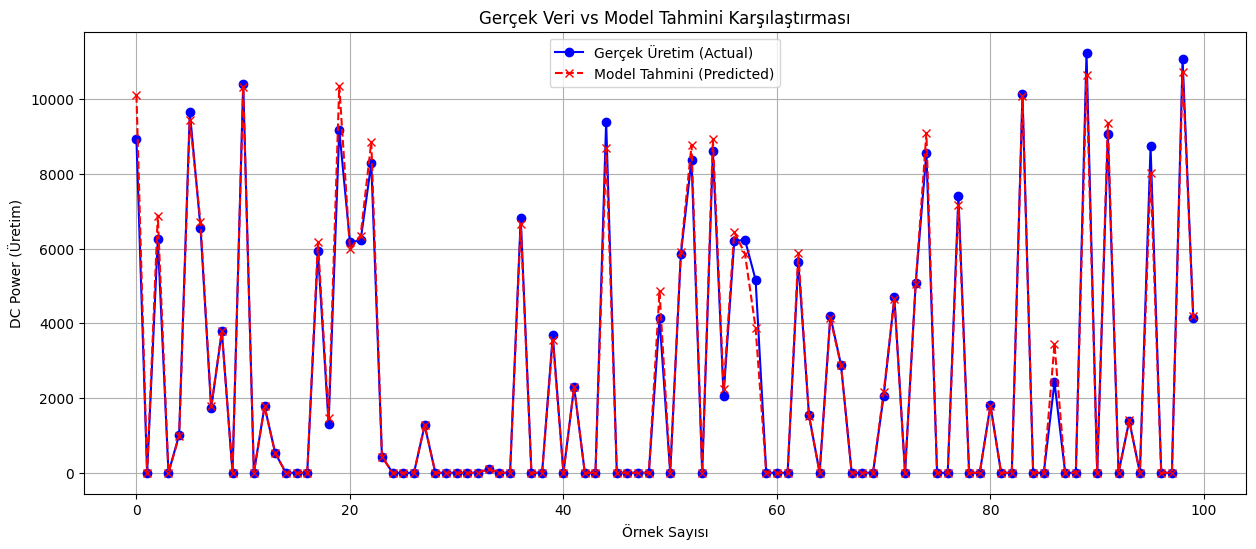

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(y_test.values[:100], label='Gerçek Üretim (Actual)', color='blue', marker='o')
plt.plot(y_pred[:100], label='Model Tahmini (Predicted)', color='red', linestyle='--', marker='x')

plt.title('Gerçek Veri vs Model Tahmini Karşılaştırması')
plt.xlabel('Örnek Sayısı')
plt.ylabel('DC Power (Üretim)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    results.append({"Model": name, "R2 Skoru": r2, "MAE": mae})

compare_df = pd.DataFrame(results)
display(compare_df.sort_values(by="R2 Skoru", ascending=False))

,Model,R2 Skoru,MAE
1,Decision Tree,0.986404,168.392328
2,Random Forest,0.986374,168.379704
0,Linear Regression,0.980106,266.264856


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN (K-Nearest Neighbors)": KNeighborsRegressor(n_neighbors=5),
    "SVM": SVR(kernel='rbf', cache_size=1000)
}

results = []

for name, model in models.items():
    if name in ["KNN (K-Nearest Neighbors)", "SVM"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    results.append({"Model": name, "R2 Skoru": r2, "MAE": mae})

compare_df = pd.DataFrame(results)
print("Sonuçlar:")
display(compare_df.sort_values(by="R2 Skoru", ascending=False))

Sonuçlar:


,Model,R2 Skoru,MAE
1,Decision Tree,0.986404,168.392328
2,Random Forest,0.986374,168.379704
3,KNN (K-Nearest Neighbors),0.984880,174.625932
0,Linear Regression,0.980106,266.264856
4,SVM,0.929908,524.728859


In [ ]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f"Her bir katman için R2 skorları: {cv_scores}")
print(f"Ortalama R2 Skoru: {cv_scores.mean():.4f}")
print(f"Standart Sapma: {cv_scores.std():.4f}")

Her bir katman için R2 skorları: [0.98779417 0.98256355 0.98583394 0.9655319  0.97871399]
Ortalama R2 Skoru: 0.9801
Standart Sapma: 0.0079


Ortalama Mutlak Hata (MAE): 168.38
Hata Kareler Ortalaması (MSE): 220188.80
Ortalama Hata Karekökü (RMSE): 469.24
R2 Skoru (Başarı Oranı): %98.64


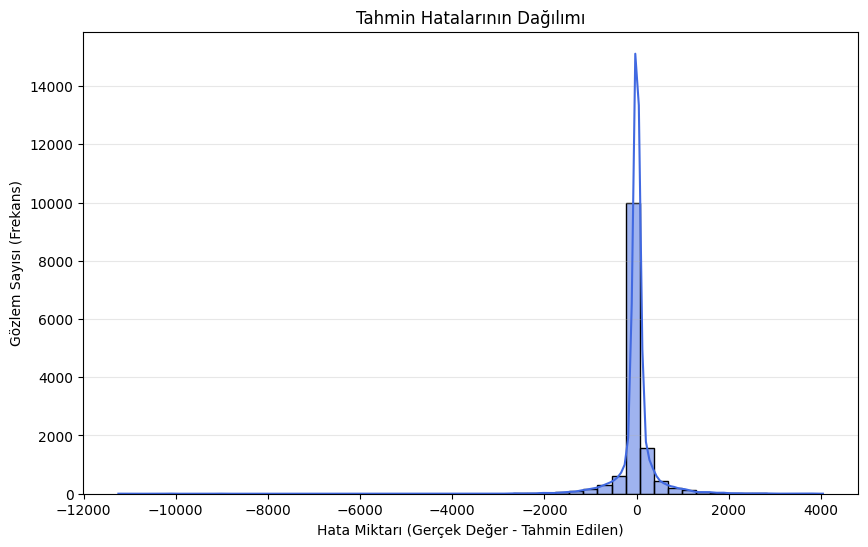

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Ortalama Mutlak Hata (MAE): {mae:.2f}")
print(f"Hata Kareler Ortalaması (MSE): {mse:.2f}")
print(f"Ortalama Hata Karekökü (RMSE): {rmse:.2f}")
print(f"R2 Skoru (Başarı Oranı): %{r2*100:.2f}")

errors = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, bins=50, color='royalblue')
plt.title('Tahmin Hatalarının Dağılımı')
plt.xlabel('Hata Miktarı (Gerçek Değer - Tahmin Edilen)')
plt.ylabel('Gözlem Sayısı (Frekans)')
plt.grid(axis='y', alpha=0.3)
plt.show()